# RVC Selective Weight Blending (Element-Level)

1. Computes weight differences between model A and B at the element level
2. Selects TOP X% of elements with the largest differences (using RATIO)
3. Linearly interpolates these weights: `result = (1 - BLEND_FACTOR) * B + BLEND_FACTOR * A`
4. Unselected weights remain 100% model B

In [99]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import List, Dict, Tuple
import datetime

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.3.1


In [100]:
# ===== CONFIGURATION =====

# Two models for comparison
# Weights are blended from A into B
MODEL_A = "Ravdess_F_Angry_60e_1140s.pth"
MODEL_B = "Ravdess_F_Neutral_111e_1110s.pth"

RATIO = 0.3
BLEND_FACTOR = 1
MODULES = None
OUTPUT_PATH = "03_1.pth"

In [101]:
def load_checkpoint(path: str) -> dict:
    """Load checkpoint from .pth file."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found: {path}")
    cpt = torch.load(path, map_location="cpu")
    print(f"Loaded: {os.path.basename(path)} (SR: {cpt.get('sr')}, v: {cpt.get('version')})")
    return cpt

def extract_weights(cpt: dict) -> OrderedDict:
    """Extract weights from checkpoint (filters enc_q)."""
    weights = cpt.get("model") or cpt.get("weight")
    if weights is None:
        raise ValueError("Unknown checkpoint format")
    return OrderedDict((k, v) for k, v in weights.items() if "enc_q" not in k)

def compute_all_differences(
    cpt_a: dict, 
    cpt_b: dict,
    modules: List[str] = None
) -> Tuple[Dict[str, torch.Tensor], Dict[str, dict]]:
    """
    Compute weight differences between two models at the element level.
    
    Returns:
        diff_tensors: Dict {layer_name: abs_diff_tensor}
        stats: Dict {layer_name: {"mean", "max", "numel", "shape"}}
    """
    w_a = extract_weights(cpt_a)
    w_b = extract_weights(cpt_b)
    
    diff_tensors = {}
    stats = {}
    
    for key in w_a.keys():
        # Module filter
        if modules is not None:
            if not any(m in key for m in modules) and "bias" not in key:
                continue
        
        if key not in w_b:
            continue
            
        a = w_a[key].float()
        b = w_b[key].float()
        
        if a.shape != b.shape:
            continue
        
        diff = (a - b).abs()
        diff_tensors[key] = diff
        
        stats[key] = {
            "mean": diff.mean().item(),
            "max": diff.max().item(),
            "numel": a.numel(),
            "shape": list(a.shape)
        }
    
    return diff_tensors, stats


def compute_threshold(diff_tensors: Dict[str, torch.Tensor], ratio: float) -> float:
    """
    Compute threshold for selecting TOP ratio% weights.
    """
    # Concatenate all differences into one vector
    all_diffs = torch.cat([d.flatten() for d in diff_tensors.values()])
    total = all_diffs.numel()
    
    # Number of weights to select
    k = int(total * ratio)
    k = max(1, min(k, total))  # At least 1, max all
    
    # Find the k-th largest element (threshold)
    threshold = torch.kthvalue(all_diffs, total - k + 1).values.item()
    
    print(f"Total parameters: {total:,}")
    print(f"Ratio: {ratio} -> selecting {k:,} weights ({100*ratio:.2f}%)")
    print(f"Threshold: {threshold:.8f}")
    
    return threshold


def create_copy_masks(
    diff_tensors: Dict[str, torch.Tensor], 
    threshold: float
) -> Tuple[Dict[str, torch.Tensor], Dict[str, int]]:
    """
    Create binary masks for weight blending.
    
    Returns:
        masks: Dict {layer_name: bool_tensor} where True = blend
        counts: Dict {layer_name: number_of_selected_elements}
    """
    masks = {}
    counts = {}
    
    for key, diff in diff_tensors.items():
        mask = diff >= threshold
        masks[key] = mask
        counts[key] = mask.sum().item()
    
    total_selected = sum(counts.values())
    print(f"Total selected weights: {total_selected:,}")
    
    return masks, counts

def apply_mask_blend(
    source_cpt: dict,
    target_cpt: dict,
    masks: Dict[str, torch.Tensor],
    blend_factor: float = 0.5
) -> OrderedDict:
    """
    Blend selected weights (according to masks) from source into target model.
    
    For selected weights: result = (1 - blend_factor) * target + blend_factor * source
    For unselected weights: result = target
    """
    source_weights = extract_weights(source_cpt)
    target_weights = extract_weights(target_cpt)
    
    result = OrderedDict()
    blended_total = 0
    
    for key in target_weights.keys():
        tgt = target_weights[key].float()
        
        if key in masks and key in source_weights:
            src = source_weights[key].float()
            mask = masks[key]
            
            if src.shape == tgt.shape:
                blended = (1 - blend_factor) * tgt + blend_factor * src
                result[key] = torch.where(mask, blended, tgt)
                blended_total += mask.sum().item()
            else:
                result[key] = tgt
        else:
            result[key] = tgt
    
    print(f"Blended {blended_total:,} individual weights (factor={blend_factor})")
    return result


def save_model(weights: OrderedDict, base_cpt: dict, output_path: str, info: str = "") -> str:
    """Save model."""
    opt = OrderedDict()
    opt["weight"] = OrderedDict((k, v.half()) for k, v in weights.items())
    opt["config"] = base_cpt.get("config")
    opt["sr"] = base_cpt.get("sr")
    opt["f0"] = base_cpt.get("f0", 1)
    opt["version"] = base_cpt.get("version", "v2")
    opt["creation_date"] = datetime.datetime.now().isoformat()
    opt["info"] = info
    
    torch.save(opt, output_path)
    print(f"Saved: {output_path} ({os.path.getsize(output_path) / 1024 / 1024:.2f} MB)")
    return output_path


print("Functions ready.")

Functions ready.


In [102]:
# ===== 1. LOAD MODELS =====

cpt_a = load_checkpoint(MODEL_A)
cpt_b = load_checkpoint(MODEL_B)

# ===== 2. COMPUTE DIFFERENCES AT ELEMENT LEVEL =====

print("\nComputing weight differences at element level...")
diff_tensors, stats = compute_all_differences(cpt_a, cpt_b, MODULES)
print(f"Analyzed {len(diff_tensors)} layers")

# ===== 3. COMPUTE THRESHOLD AND MASKS =====

print(f"\nComputing threshold for RATIO={RATIO}...")
threshold = compute_threshold(diff_tensors, RATIO)

print("\nCreating masks for copying...")
masks, element_counts = create_copy_masks(diff_tensors, threshold)

Loaded: Ravdess_F_Angry_60e_1140s.pth (SR: 48000, v: v2)
Loaded: Ravdess_F_Neutral_111e_1110s.pth (SR: 48000, v: v2)

Computing weight differences at element level...
Analyzed 457 layers

Computing threshold for RATIO=0.3...
Total parameters: 28,716,994
Ratio: 0.3 -> selecting 8,615,098 weights (30.00%)
Threshold: 0.00442505

Creating masks for copying...
Total selected weights: 8,635,677


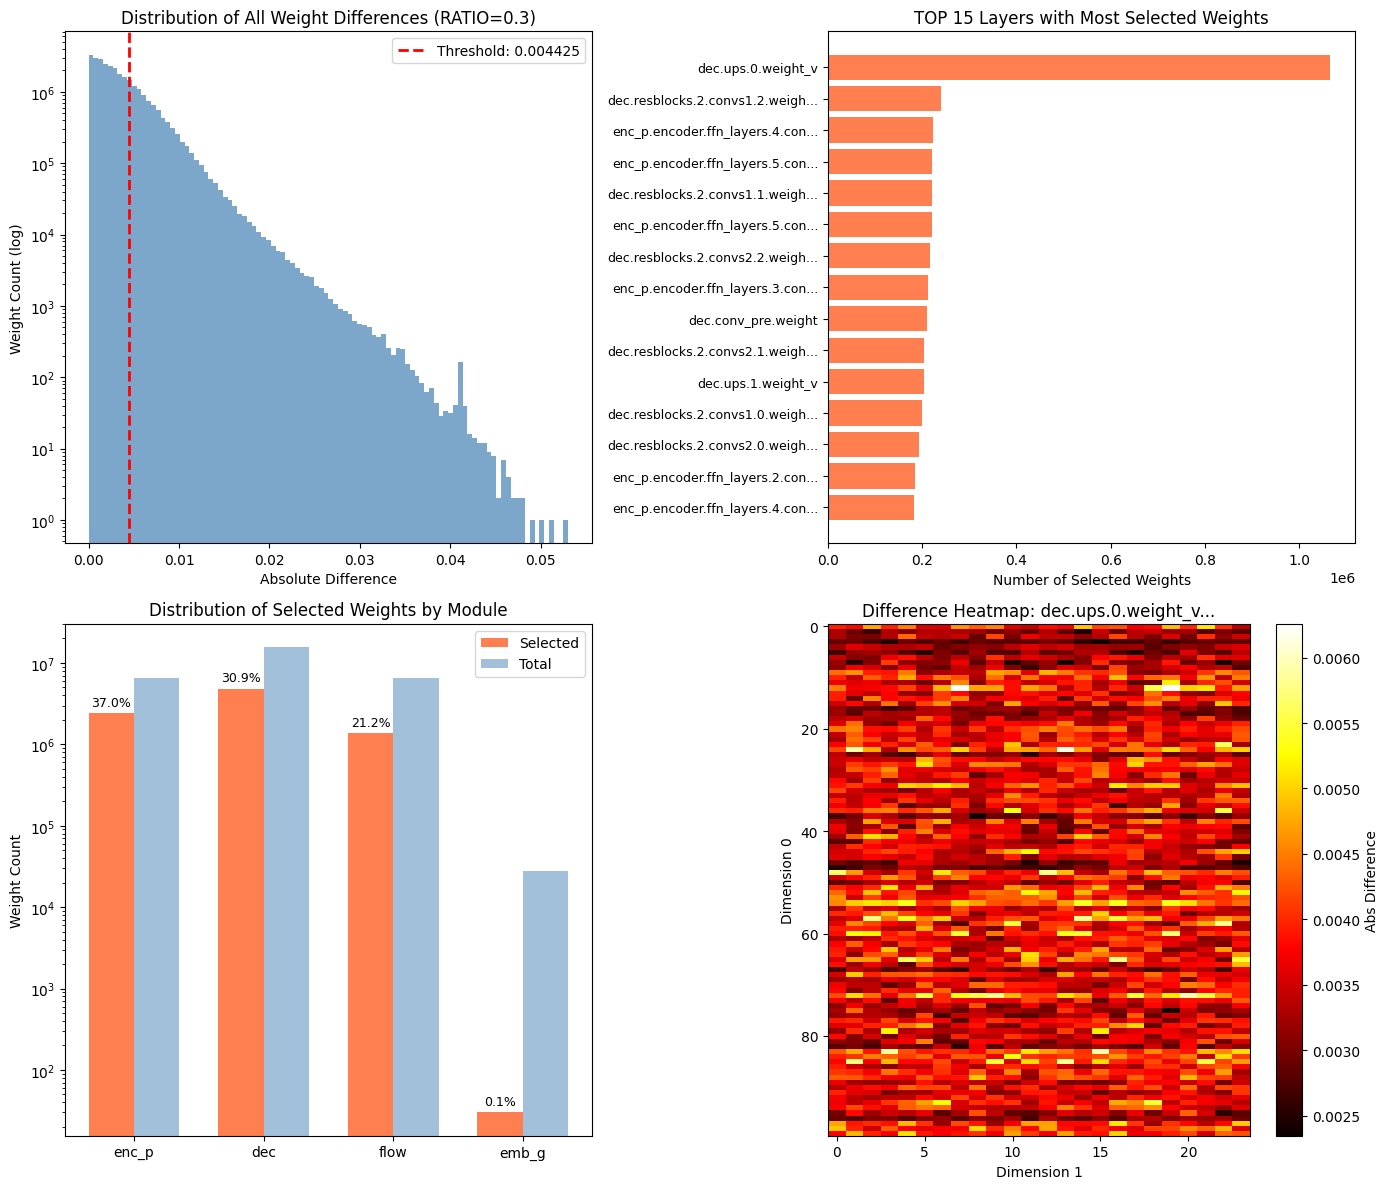


Statistics:
  Total layers: 457
  Total parameters: 28,716,994
  Selected weights: 8,635,677 (30.00%)
  Threshold: 0.00442505


In [103]:
# ===== VISUALIZATION =====

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Chart 1: Histogram of all differences ---
ax1 = axes[0, 0]
all_diffs = torch.cat([d.flatten() for d in diff_tensors.values()]).numpy()
ax1.hist(all_diffs, bins=100, color='steelblue', edgecolor='none', alpha=0.7, log=True)
ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:.6f}')
ax1.set_xlabel('Absolute Difference')
ax1.set_ylabel('Weight Count (log)')
ax1.set_title(f'Distribution of All Weight Differences (RATIO={RATIO})')
ax1.legend()

# --- Chart 2: TOP layers by number of selected elements ---
ax2 = axes[0, 1]
sorted_counts = sorted(element_counts.items(), key=lambda x: x[1], reverse=True)[:15]
layers_short = [l[:30] + "..." if len(l) > 30 else l for l, _ in sorted_counts]
counts_vals = [c for _, c in sorted_counts]
ax2.barh(range(len(layers_short)), counts_vals, color='coral')
ax2.set_yticks(range(len(layers_short)))
ax2.set_yticklabels(layers_short, fontsize=9)
ax2.set_xlabel('Number of Selected Weights') 
ax2.set_title('TOP 15 Layers with Most Selected Weights')
ax2.invert_yaxis()

# --- Chart 3: Distribution by modules ---
ax3 = axes[1, 0]
module_counts = {"enc_p": 0, "dec": 0, "flow": 0, "emb_g": 0, "other": 0}
module_totals = {"enc_p": 0, "dec": 0, "flow": 0, "emb_g": 0, "other": 0}

for layer, count in element_counts.items():
    matched = False
    for m in ["enc_p", "dec", "flow", "emb_g"]:
        if layer.startswith(m):
            module_counts[m] += count
            module_totals[m] += stats[layer]["numel"]
            matched = True
            break
    if not matched:
        module_counts["other"] += count
        module_totals["other"] += stats[layer]["numel"]

# Only modules with data
modules_with_data = [(m, c, module_totals[m]) for m, c in module_counts.items() if module_totals[m] > 0]
mod_names = [m for m, _, _ in modules_with_data]
mod_selected = [c for _, c, _ in modules_with_data]
mod_total = [t for _, _, t in modules_with_data]
mod_pct = [100 * s / t if t > 0 else 0 for s, t in zip(mod_selected, mod_total)]

x = np.arange(len(mod_names))
width = 0.35
bars1 = ax3.bar(x - width/2, mod_selected, width, label='Selected', color='coral')
bars2 = ax3.bar(x + width/2, mod_total, width, label='Total', color='steelblue', alpha=0.5)
ax3.set_ylabel('Weight Count')
ax3.set_title('Distribution of Selected Weights by Module')
ax3.set_xticks(x)
ax3.set_xticklabels(mod_names)
ax3.legend()
ax3.set_yscale('log')

# Add percentages above bars
for i, (rect, pct) in enumerate(zip(bars1, mod_pct)):
    ax3.annotate(f'{pct:.1f}%', xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# --- Chart 4: Heatmap for layer with most selected weights ---
ax4 = axes[1, 1]
top_layer = sorted_counts[0][0] if sorted_counts else None
if top_layer and len(diff_tensors[top_layer].shape) >= 2:
    diff_2d = diff_tensors[top_layer]
    # If more than 2D, average other dimensions
    while len(diff_2d.shape) > 2:
        diff_2d = diff_2d.mean(dim=0)
    
    # Limit size for display
    max_size = 100
    if diff_2d.shape[0] > max_size:
        diff_2d = diff_2d[:max_size, :]
    if diff_2d.shape[1] > max_size:
        diff_2d = diff_2d[:, :max_size]
    
    im = ax4.imshow(diff_2d.numpy(), aspect='auto', cmap='hot')
    plt.colorbar(im, ax=ax4, label='Abs Difference')
    ax4.set_title(f'Difference Heatmap: {top_layer[:40]}...')
    ax4.set_xlabel('Dimension 1')
    ax4.set_ylabel('Dimension 0')
else:
    ax4.text(0.5, 0.5, 'N/A (1D tensor)', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Difference Heatmap')

plt.tight_layout()
plt.show()

# Statistics table
print(f"\nStatistics:")
print(f"  Total layers: {len(diff_tensors)}")
print(f"  Total parameters: {sum(s['numel'] for s in stats.values()):,}")
print(f"  Selected weights: {sum(element_counts.values()):,} ({100*RATIO:.2f}%)")
print(f"  Threshold: {threshold:.8f}")

In [104]:
# ===== 4. BLEND WEIGHTS =====

print(f"Blending selected weights from model A into model B")
print(f"  Source: {MODEL_A}")
print(f"  Target: {MODEL_B}")
print(f"  Selected weights: {sum(element_counts.values()):,}")
print(f"  Blend factor: {BLEND_FACTOR} ({BLEND_FACTOR*100:.0f}% A + {(1-BLEND_FACTOR)*100:.0f}% B)")

# Blend using masks (from A into B)
result_weights = apply_mask_blend(cpt_a, cpt_b, masks, BLEND_FACTOR)

# Calculate percentage of total model
all_weights = extract_weights(cpt_b)
total_model_params = sum(w.numel() for w in all_weights.values())
blended_count = sum(element_counts.values())
pct_of_total = 100 * blended_count / total_model_params

print(f"  Weights blended: {blended_count:,} / {total_model_params:,} ({pct_of_total:.2f}% of total model)")

# Save
info = f"Blended {RATIO*100:.1f}% most different weights (factor={BLEND_FACTOR}) from {os.path.basename(MODEL_A)} into {os.path.basename(MODEL_B)}"
save_model(result_weights, cpt_b, OUTPUT_PATH, info)

print(f"\nDone!")

Blending selected weights from model A into model B
  Source: Ravdess_F_Angry_60e_1140s.pth
  Target: Ravdess_F_Neutral_111e_1110s.pth
  Selected weights: 8,635,677
  Blend factor: 1 (100% A + 0% B)
Blended 8,635,677 individual weights (factor=1)
  Weights blended: 8,635,677 / 28,716,994 (30.07% of total model)
Saved: 03_1.pth (54.88 MB)

Done!


In [105]:
import inference
inference.run_pipeline(
    0, 
    "Angry++.wav", # real path: /workspace/rvc-cli/input-audio.wav
    OUTPUT_PATH[:-4] + ".wav", # real path: /workspace/rvc-cli/output-audio.wav
    OUTPUT_PATH) # real path: /workspace/rvc-cli/path-to-pth-file.pth

2026-02-06 11:06:59,385 | inference.log | INFO: Starting RVC inference...
2026-02-06 11:06:59,385 | inference.log | INFO: Running inference...
2026-02-06 11:06:59,386 | inference.log | INFO: ===INFER===
2026-02-06 11:06:59,387 | inference.log | INFO: pitch 0
2026-02-06 11:06:59,387 | inference.log | INFO: filter_radius 3
2026-02-06 11:06:59,387 | inference.log | INFO: index_rate 0
2026-02-06 11:06:59,388 | inference.log | INFO: volume_envelope 0.8
2026-02-06 11:06:59,388 | inference.log | INFO: protect 0.33
2026-02-06 11:06:59,388 | inference.log | INFO: hop_length 128
2026-02-06 11:06:59,389 | inference.log | INFO: f0_method rmvpe
2026-02-06 11:06:59,389 | inference.log | INFO: input_path Angry++.wav
2026-02-06 11:06:59,389 | inference.log | INFO: output_path 03_1.wav
2026-02-06 11:06:59,389 | inference.log | INFO: pth_path 03_1.pth
2026-02-06 11:06:59,390 | inference.log | INFO: index_path file.index
2026-02-06 11:06:59,390 | inference.log | INFO: split_audio False
2026-02-06 11:06:5

Running inference...


2026-02-06 11:06:59,402 | inference.log | INFO: chorus_mix 0.5
2026-02-06 11:06:59,402 | inference.log | INFO: bitcrush_bit_depth 8
2026-02-06 11:06:59,403 | inference.log | INFO: clipping_threshold -6
2026-02-06 11:06:59,403 | inference.log | INFO: compressor_threshold 0.0
2026-02-06 11:06:59,403 | inference.log | INFO: compressor_ratio 1
2026-02-06 11:06:59,403 | inference.log | INFO: compressor_attack 1.0
2026-02-06 11:06:59,404 | inference.log | INFO: compressor_release 100
2026-02-06 11:06:59,404 | inference.log | INFO: delay_seconds 0.5
2026-02-06 11:06:59,404 | inference.log | INFO: delay_feedback 0.0
2026-02-06 11:06:59,405 | inference.log | INFO: delay_mix 0.5
2026-02-06 11:06:59,405 | inference.log | INFO: ===========
2026-02-06 11:06:59,405 | inference.log | INFO: Running command: venv/bin/python3 rvc_cli.py infer --pitch 0 --filter_radius 3 --index_rate 0 --volume_envelope 0.8 --protect 0.33 --hop_length 128 --f0_method rmvpe --input_path Angry++.wav --output_path 03_1.wav 

Audio output:  03_1.wav


2026-02-06 11:07:04,584 | inference.log | INFO: Conversion completed at '03_1.wav' in 1.71 seconds.
2026-02-06 11:07:05,176 | inference.log | INFO: Output file saved to '03_1.wav'
2026-02-06 11:07:05,177 | inference.log | INFO: Inference completed successfully!


Output file saved to '03_1.wav'
Inference completed successfully!
